# **Kernel PCA on Billionaires Dataset**
Understand the principal components that explain variation in actual wealth, not ranking.

We will:

Use log(networth) as target

Apply PCA and Kernel PCA

Compare predictive power

Interpret economic meaning

In [22]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA, KernelPCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score


plt.style.use("seaborn-v0_8")

In [5]:
#load data :
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%203/data/billionaires.csv"

df = pd.read_csv(url, index_col="Unnamed: 0")

df.head()

,rank,name,networth,age,country,source,industry
0,1,Elon Musk,$219 B,50,United States,"Tesla, SpaceX",Automotive
1,2,Jeff Bezos,$171 B,58,United States,Amazon,Technology
2,3,Bernard Arnault & family,$158 B,73,France,LVMH,Fashion & Retail
3,4,Bill Gates,$129 B,66,United States,Microsoft,Technology
4,5,Warren Buffett,$118 B,91,United States,Berkshire Hathaway,Finance & Investments


In [6]:
#quick EDA :
print(df.info())
print(df.describe())
print(df.shape)
print(df.columns)
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 2600 entries, 0 to 2599
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   rank      2600 non-null   int64 
 1   name      2600 non-null   object
 2   networth  2600 non-null   object
 3   age       2600 non-null   int64 
 4   country   2600 non-null   object
 5   source    2600 non-null   object
 6   industry  2600 non-null   object
dtypes: int64(2), object(5)
memory usage: 162.5+ KB
None
              rank          age
count  2600.000000  2600.000000
mean   1269.570769    64.271923
std     728.146364    13.220607
min       1.000000    19.000000
25%     637.000000    55.000000
50%    1292.000000    64.000000
75%    1929.000000    74.000000
max    2578.000000   100.000000
(2600, 7)
Index(['rank', 'name', 'networth', 'age', 'country', 'source', 'industry'], dtype='object')
rank        0
name        0
networth    0
age         0
country     0
source      0
industry    0
dtype: int64

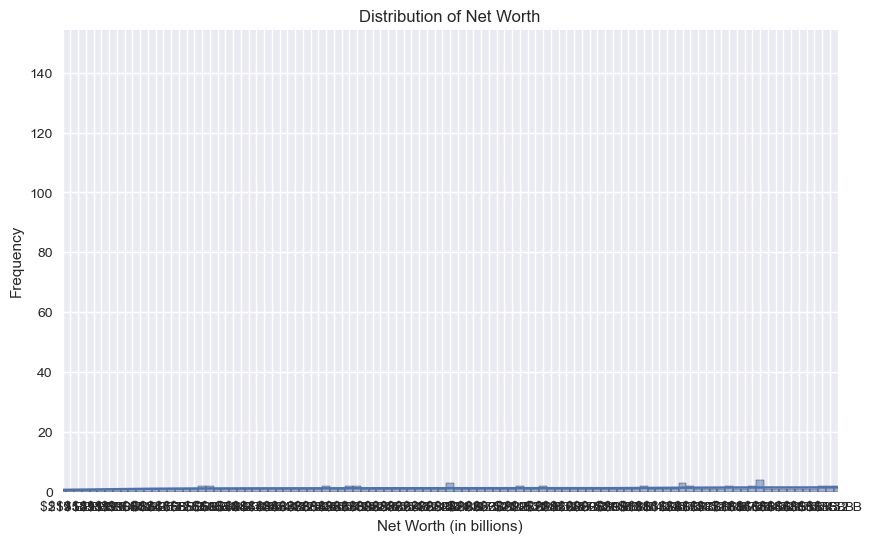

In [9]:
#Inspect Wealth Distribution
plt.figure(figsize=(10, 6)) 
sns.histplot(df['networth'], bins=30, kde=True)
plt.title('Distribution of Net Worth')
plt.xlabel('Net Worth (in billions)')
plt.ylabel('Frequency')
plt.xlim(0, 100)
plt.show()

##### Problem : Extreme skew
	Log-normal distribution (few megabillionaires, many "mere" billionaires)
##### Solution : Log(Net Worth)
    Compresses the tail
    Keeps magnitude information
    More "linear" in feature space

   rank                       name networth  age        country  \
0     1                 Elon Musk    $219 B   50  United States   
1     2                Jeff Bezos    $171 B   58  United States   
2     3  Bernard Arnault & family    $158 B   73         France   
3     4                Bill Gates    $129 B   66  United States   
4     5            Warren Buffett    $118 B   91  United States   

               source                industry  
0       Tesla, SpaceX             Automotive   
1              Amazon             Technology   
2                LVMH       Fashion & Retail   
3           Microsoft             Technology   
4  Berkshire Hathaway  Finance & Investments   


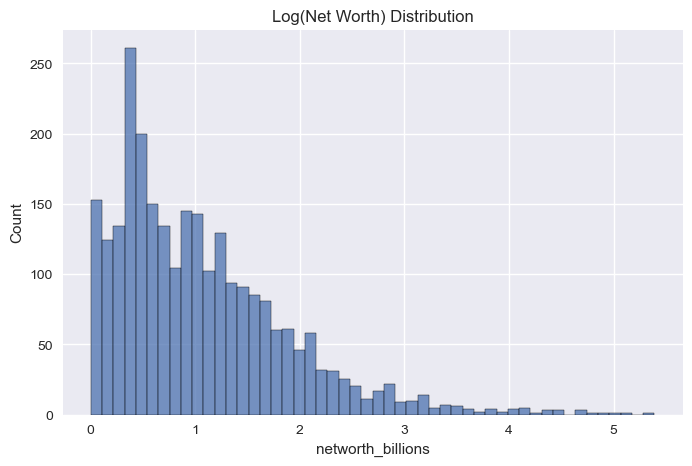

In [13]:
print(df.head())
# we need to convert networth to numeric value to use log transformation

# Step 1: Clean the string
df['networth_clean'] = (
    df['networth']
    .str.replace('$', '', regex=False)   # Remove dollar sign
    .str.replace('B', '', regex=False)   # Remove B (billions)
    .str.replace('M', '', regex=False)   # Remove M (millions)
)

# Step 2: Convert to float
df['networth_num'] = pd.to_numeric(df['networth_clean'], errors='coerce')

# Step 3: Adjust scale (B = billions, M = millions)
# If your data has mixed B and M, you need to handle that:
df['networth_billions'] = df.apply(
    lambda row: row['networth_num'] * 1000 if 'M' in str(row['networth']) 
    else row['networth_num'], 
    axis=1
)

# Step 4: Now take log
y = np.log(df['networth_billions'])
plt.figure(figsize=(8,5))
sns.histplot(y, bins=50)
plt.title("Log(Net Worth) Distribution")
plt.show()


the distribution is much more Gaussian like after the log Transform 

In [14]:
# 2. Drop ALL target-related columns + useless ID columns
drop_cols = [
    "name",           # ID, not predictive
    "rank",           # Derived from networth (data leakage!)
    "networth",       # Original string
    "networth_clean", # Intermediate cleaning
    "networth_billions",  # Your numeric target
    "networth_num"    # Any other variants you created
]

df_model = df.drop(columns=drop_cols)

3. What should remain for features:
 - age
 - country  
 - industry
 - source        ← KEEP THIS! (company/source of wealth)
 - gender
 - selfMade
 - etc.

In [16]:
print(f"\nRemaining columns: {df_model.columns.tolist()}")
print(f"\nData types:\n{df_model.dtypes}")



Remaining columns: ['age', 'country', 'source', 'industry']

Data types:
age          int64
country     object
source      object
industry    object
dtype: object


In [17]:
categorical_cols = ["country", "industry", "source"]
print(f"\nCategorical columns to encode: {categorical_cols}")



Categorical columns to encode: ['country', 'industry', 'source']


In [18]:
# One-Hot Encode categorical features
preprocessor = ColumnTransformer(
    transformers =[
        ("onehot", OneHotEncoder(handle_unknown='ignore' , sparse_output=False), categorical_cols)
    ], 
    remainder='passthrough' # keep numeric columns as is

)
X_preprocessed = preprocessor.fit_transform(df_model)
feature_names = preprocessor.get_feature_names_out()
X = pd.DataFrame(X_preprocessed, columns=feature_names)
print(f"\nPreprocessed feature matrix shape: {X.shape}")
print(f"\nSample of preprocessed features:\n{X.head()}")



Preprocessed feature matrix shape: (2600, 989)

Sample of preprocessed features:
   onehot__country_Algeria  onehot__country_Argentina  \
0                      0.0                        0.0   
1                      0.0                        0.0   
2                      0.0                        0.0   
3                      0.0                        0.0   
4                      0.0                        0.0   

   onehot__country_Australia  onehot__country_Austria  \
0                        0.0                      0.0   
1                        0.0                      0.0   
2                        0.0                      0.0   
3                        0.0                      0.0   
4                        0.0                      0.0   

   onehot__country_Barbados  onehot__country_Belgium  onehot__country_Belize  \
0                       0.0                      0.0                     0.0   
1                       0.0                      0.0                    

In [19]:
#Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\nScaled feature matrix shape: {X_scaled.shape}")


Scaled feature matrix shape: (2600, 989)


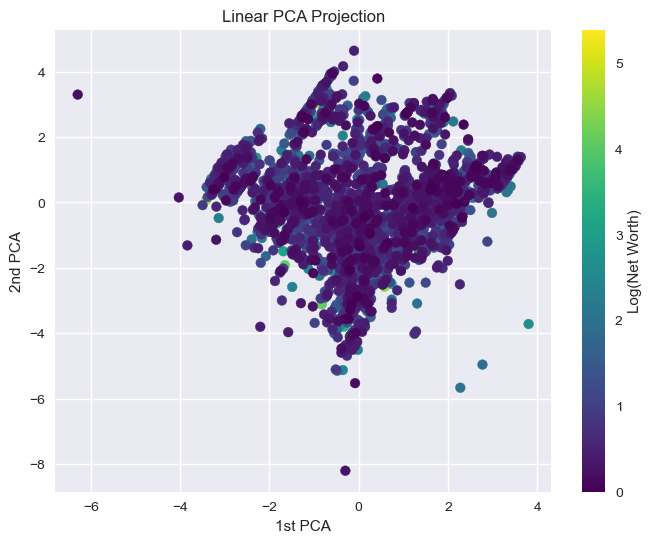

In [20]:
# apply linear PCA :
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

#visualize :
plt.figure(figsize=(8,6))
sc = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis"
)
plt.colorbar(sc, label="Log(Net Worth)")
plt.xlabel("1st PCA")
plt.ylabel("2nd PCA")
plt.title("Linear PCA Projection")
plt.show()

#### Observations (Linear PCA)

- **No clear clusters:**  
  Points form one dense cloud.  
  There is no strong natural grouping in your data (at least linearly).

- **Most points are near the center:**  
  Most individuals have similar feature structure.  
  Extreme values are rare (outliers are far from center).

- **They are not forming a separate region:**  
  Net worth is probably not strongly separable using linear combinations of features.



### Kernel PCA :

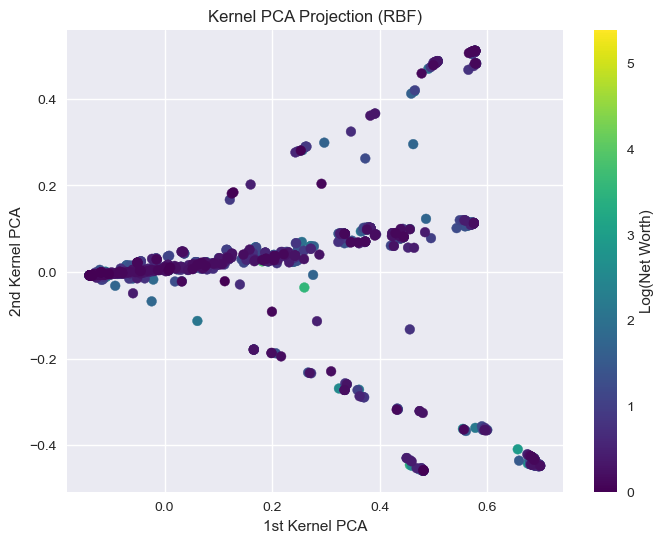

In [30]:
kpca = KernelPCA(n_components=10,
    kernel="rbf",
    gamma=0.01,  # Try 0.001, 0.01, 0.1, 1.0 and compare
    fit_inverse_transform=False,  # Set True only if you need inverse transform (slow)
    alpha=0.1  # Regularization for numerical stability
    )
X_kpca = kpca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sc = plt.scatter(
    X_kpca[:, 0],
    X_kpca[:, 1],
    c=y,
    cmap="viridis"
)
plt.colorbar(sc, label="Log(Net Worth)")
plt.xlabel("1st Kernel PCA")
plt.ylabel("2nd Kernel PCA")
plt.title("Kernel PCA Projection (RBF)")
plt.show()

### Observations (Kernel PCA)

- **Clear curved structures**

- **Horizontal bands**

- **Separation along nonlinear shapes**

- **Most points are dark (low wealth)**

- **Some brighter points appear scattered**

- **A few higher values appear on branches**

In [31]:
# Regression Comparison
X_train_pca , X_test_pca , y_train , y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)
model_pca = Ridge(alpha=1.0)
model_pca.fit(X_train_pca, y_train)

y_pred_pca = model_pca.predict(X_test_pca)
r2_pca = r2_score(y_test, y_pred_pca)

print(f"R² Score with Linear PCA: {r2_pca:.4f}")

#KErnel PCA Regression
X_train_kpca , X_test_kpca , y_train , y_test = train_test_split(X_kpca, y, test_size=0.2, random_state=42)
model_kpca = Ridge(alpha=1.0)
model_kpca.fit(X_train_kpca, y_train)

y_pred_kpca = model_kpca.predict(X_test_kpca)
r2_kpca = r2_score(y_test, y_pred_kpca)
print(f"R² Score with Kernel PCA: {r2_kpca:.4f}")


R² Score with Linear PCA: 0.0163
R² Score with Kernel PCA: 0.0121


R^2 measures -> How much of the variance in Net Worth your model explains
That is extremely low

    -**the model is almost guessing**

In [33]:
# Use Random Forest to see if ANY features matter
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
print(feature_importance.sort_values(ascending=False).head(20))

# If top importance is < 0.01, your features are weak
from sklearn.metrics import r2_score

y_pred = rf.predict(X)
print(r2_score(y, y_pred))

remainder__age                             0.196650
onehot__source_Google                      0.018720
onehot__source_Walmart                     0.015908
onehot__country_United States              0.015443
onehot__source_Amazon                      0.012084
onehot__source_Microsoft                   0.011896
onehot__source_Koch Industries             0.011569
onehot__source_Tesla, SpaceX               0.009693
onehot__country_China                      0.009338
onehot__country_Hong Kong                  0.008750
onehot__country_Germany                    0.008633
onehot__country_France                     0.008119
onehot__industry_Finance & Investments     0.007945
onehot__country_India                      0.007765
onehot__source_LVMH                        0.007652
onehot__source_candy, pet food             0.007502
onehot__source_investments                 0.007483
onehot__industry_Technology                0.007473
onehot__source_hedge funds                 0.007082
onehot__sour

### **Conclusion on Feature Importance**:

    -The Random Forest feature importance analysis shows that age is by far the most influential predictor of net worth, with an importance score significantly higher than all other variables. This suggests that wealth accumulation is strongly associated with age, which is consistent with real-world expectations.


    -In contrast, most categorical features (such as source of wealth, country, and industry) exhibit relatively low individual importance scores. This indicates that, while they may contribute marginally, none of them independently explains a substantial portion of the variance in net worth.

**Age carries meaningful predictive information**


**Most other features have weak standalone predictive power.**


**Net worth is likely influenced by complex interactions or external factors not captured in the current feature set.**